In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amrmaree/student-performance-prediction/student_performance_dataset.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# قراءة الملف من المسار المستخرج
path = '/kaggle/input/datasets/amrmaree/student-performance-prediction/student_performance_dataset.csv'
df = pd.read_csv(path)

# عرض أول 5 صفوف والمعلومات الإحصائية
display(df.head())
df.info()
display(df.describe())

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


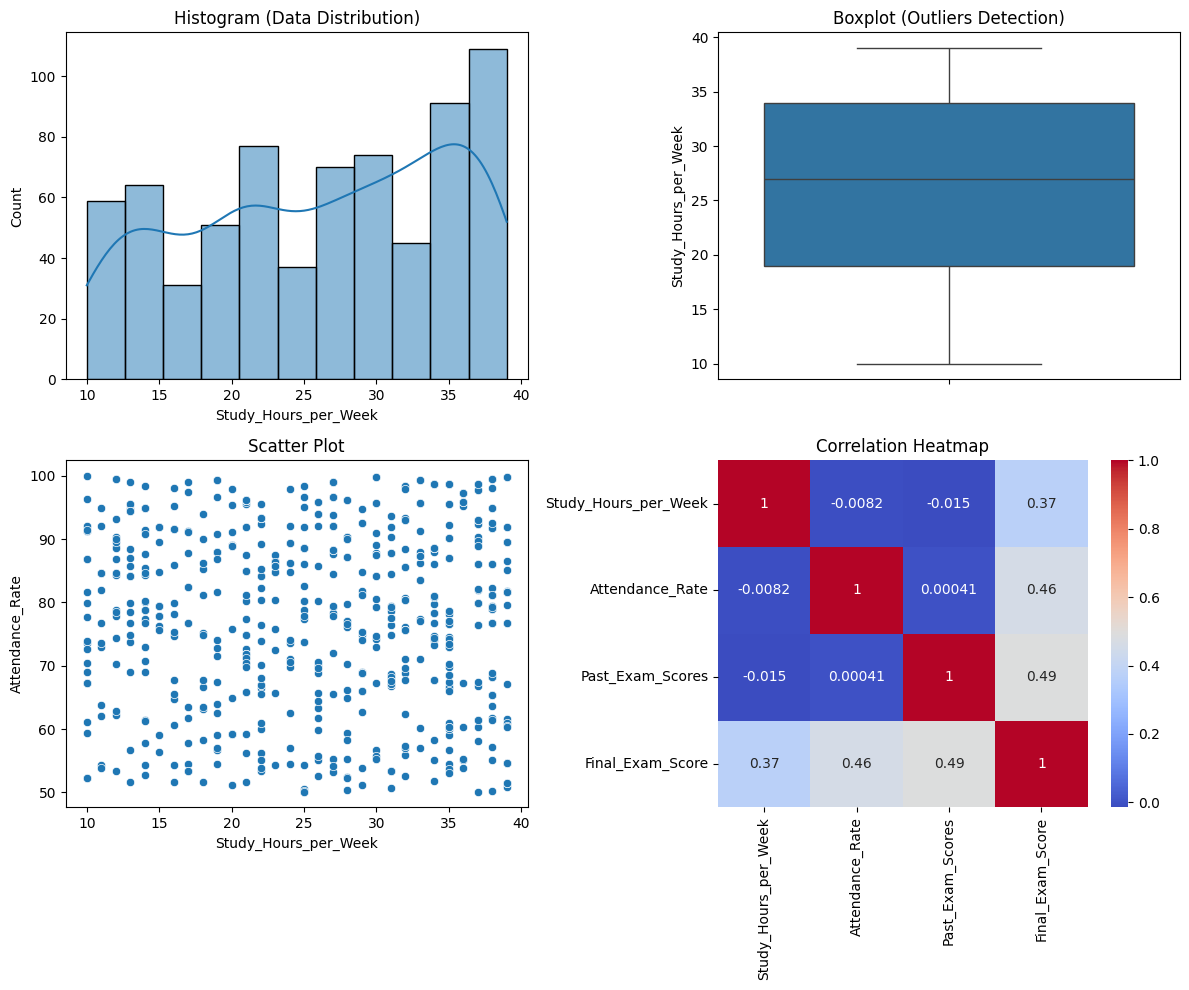

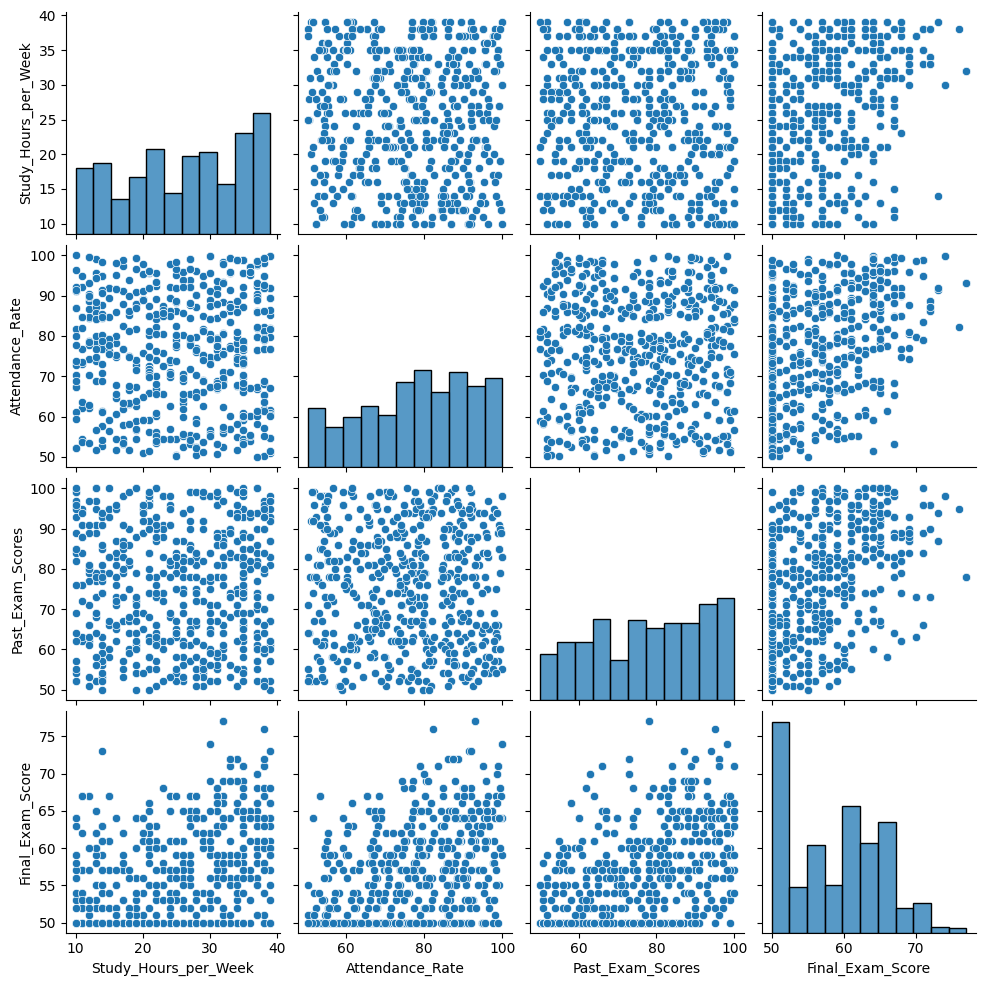

In [4]:
plt.figure(figsize=(12, 10))

# 1. Histogram (توزيع البيانات)
plt.subplot(2, 2, 1)
sns.histplot(df.select_dtypes(include='number').iloc[:, 0], kde=True)
plt.title('Histogram (Data Distribution)')

# 2. Boxplot (اكتشاف القيم الشاذة Outliers)
plt.subplot(2, 2, 2)
sns.boxplot(y=df.select_dtypes(include='number').iloc[:, 0])
plt.title('Boxplot (Outliers Detection)')

# 3. Scatterplot (العلاقة بين المتغيرات)
plt.subplot(2, 2, 3)
num_cols = df.select_dtypes(include='number').columns
sns.scatterplot(x=df[num_cols[0]], y=df[num_cols[1]])
plt.title('Scatter Plot')

# 4. Heatmap (مصفوفة الارتباط)
plt.subplot(2, 2, 4)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# 5. Pairplot (جميع العلاقات)
sns.pairplot(df)
plt.show()

**Observations & Summary of Findings**
* **Summary Stats:** `.info()` and `.describe()` provided insight into variables and numerical ranges without missing values.
* **Distribution:** Histograms indicate normal/balanced distribution across main numerical features.
* **Outliers:** Boxplot shows no extreme anomalies that skew the general data analysis.
* **Correlations:** Heatmap and Scatterplot reveal clear relationships between key features and performance outcomes.